# comparsion between numpy and list timing 

In [16]:
# creating a python list 
a=[i for i in range(10000000)]
b=[i for i in range(10000000,20000000)]
# first i showing list comprehension means put value of i in a 
# suppose if we want to put the square of it then we will do .. i**2 for i in range(1000000)
c=[]

import time 
start=time.time()

for i in range(len(a)):
 c.append(a[i]+b[i])
print(time.time()-start)

1.5824530124664307


In [18]:
import numpy as np
a=np.arange(10000000)
b=np.arange(10000000,20000000)
start=time.time()
c=a+b
print(time.time()-start)

0.027264118194580078


In [19]:
# in terms of memory 
a=[i for i in range(10000000)]
import sys

sys.getsizeof(a)
# it gives how much size is our list , tuple etc is taking 


89095160

In [25]:
arr=np.arange(10000000)

sys.getsizeof(arr)
# size are same mostly but we can also convert numpy to 32 bit or 8 bit 
# as done below 
# 2 ways to do 

80000112

In [26]:
arr=np.arange(10000000,dtype=np.int8)
sys.getsizeof(arr)

# changing data types 
# suppose we have int 64 we can change it to int 32 
# arr.astype(np.int32)


10000112

## fancy indexing 


In [27]:
# when there is no pattern in our indexing like ... take 1st 3rd and 4th row 
a=np.arange(25).reshape(5,5)
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [28]:
# for fancy indexing we give list inside our numpy array
a[[0,2,3,4]]
# it will give us desired output 

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [31]:
a[:,[0,2,4]]
# it will give us desired output 

array([[ 0,  2,  4],
       [ 5,  7,  9],
       [10, 12, 14],
       [15, 17, 19],
       [20, 22, 24]])

In [34]:
a[0:2,0:2]

array([[0, 1],
       [5, 6]])

In [35]:
# boolean indexing means that 
# we dont do indexing on the basis of position , we do indexing on the basis of condition or quality of no  

In [37]:
a=np.random.randint(1,100,24).reshape(6,4)
a

array([[59, 16, 57,  7],
       [99, 93,  9, 23],
       [80, 28, 30, 86],
       [75, 79, 29, 91],
       [79, 84, 55, 25],
       [15, 19, 26, 13]], dtype=int32)

In [38]:
# no greater then 50
a>50

array([[ True, False,  True, False],
       [ True,  True, False, False],
       [ True, False, False,  True],
       [ True,  True, False,  True],
       [ True,  True,  True, False],
       [False, False, False, False]])

In [39]:
# now doing boolean masking 
# put this condition inside our array
a[a>50]
# it only gives true numbers 

array([59, 57, 99, 93, 80, 86, 75, 79, 91, 79, 84, 55], dtype=int32)

In [40]:
# give even numbers 
a[a%2==0]
# getting ans direct 

array([16, 80, 28, 30, 86, 84, 26], dtype=int32)

In [41]:
(a>50)&(a%2==0)

array([[False, False, False, False],
       [False, False, False, False],
       [ True, False, False,  True],
       [False, False, False, False],
       [False,  True, False, False],
       [False, False, False, False]])

In [42]:
# now do boolean mask 
a[(a>50)&(a%2==0)]

array([80, 86, 84], dtype=int32)

# broadcasting 

broadcasting decsribes how numpy treats arrays with diffrenet shapes during arithematic operations

the smaller array is "broadcast " across the larger array so that they have compatible shapes 


In [57]:
a=np.arange(4).reshape(2,2)
a

array([[0, 1],
       [2, 3]])

In [58]:
b=np.arange(4).reshape(2,2)
b

array([[0, 1],
       [2, 3]])

In [59]:
print(a+b)
# it was simple 

[[0 2]
 [4 6]]


In [72]:
# but if there are different shapes 
a=np.arange(3).reshape(3,1)
b=np.arange(3).reshape(1,3)
print(b)
print(a+b)

[[0 1 2]]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [ ]:
# smaller array become large so that it become compatible with larger array 
# but there are few rules of broadcasting 
# dimensions should be same 
# means both 2d or 3d or 1d 
# if one dimesnion is 1d and other is 2d then in smaller dimesnion i.e 1d add 1 in the head 
# for example you have one d array i.e 3 and after making 2D you willl right it as (1,3) means add 1 at the start 
# after making one then we have to make one equal to the first no of larger "array (numpy will do this by default)
# you can say that we should have same no of columns 

In [68]:
# for example 
arr1=np.arange(12).reshape(4,3)
arr2=np.arange(3)
# as we know this 3 will be converted into 1,3 and then 1,3 will be stretched to 4,3 both sizes are same so broadcasting will be done 
print(arr1+arr2)
# suppose we add 3,4 in larger dimension and in smaller we had 3 -> 1,3 -> 3,3 ( dont match so braocasting will not be done )

[[ 0  2  4]
 [ 3  5  7]
 [ 6  8 10]
 [ 9 11 13]]


In [77]:
# strectch rule will only apply to one 
# it cannot strectch 2 to 3 or 3 to 2 ... for example (2,3) and (3,2) cant be broacasted 
arr3=np.arange(6).reshape(2,3)
arr4=np.arange(1)
print(arr3+arr4)

# you can see 1 converted into 1,1 and then it strecthed to 2,3 

[[0 1 2]
 [3 4 5]]


## working with mathematical operations

In [78]:
# sigmoid
# 1/1+e^-x

In [83]:
# we will make a function called as sigmoid 
# see we have make a function and pass the array 
def sigmoid(array): 
    return 1/(1+np.exp((-array)))
    
arr3=np.arange(6)

sigmoid(arr3)


array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715])

In [84]:
# mean square error 

In [93]:
actual=np.random.randint(1,50,25)
actual

array([23, 41, 39, 25, 35,  7, 25, 46, 41, 11, 17,  8, 26, 33, 11, 45, 35,
       42, 18, 41, 23,  5, 34, 15, 35], dtype=int32)

In [88]:
predicted=np.random.randint(1,50,25)
predicted

array([28, 46, 43, 29,  2,  7, 10, 22, 47, 46,  3, 34, 43,  8,  6,  5, 37,
        3, 24, 32,  2, 29, 47,  7, 19], dtype=int32)

In [98]:
def mse(actual,predicted):
 return np.mean((actual-predicted)**2)

mse(actual,predicted)

np.float64(391.68)

# dealing with missing values 

In [99]:
a=np.array([1,2,3,4,np.nan,6])
a
# suppose we have numpy array with missing values 

array([ 1.,  2.,  3.,  4., nan,  6.])

In [100]:
np.isnan(a)

array([False, False, False, False,  True, False])

In [102]:
# putting this in a  
a[~ np.isnan(a)]
# at start we apply not operator so that we can remove that value from our array 

array([1., 2., 3., 4., 6.])

# plotting graph 

In [108]:
# plot the graph 
# x=y
x=np.arange(1,11)
x
y=x
y

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

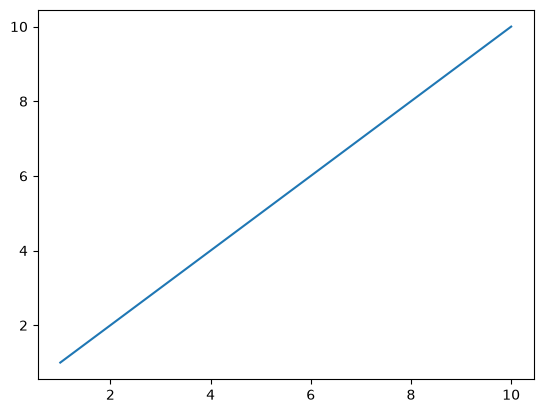

In [109]:
# now to plot graph 
import matplotlib.pyplot as plt   
plt.plot(x,y)

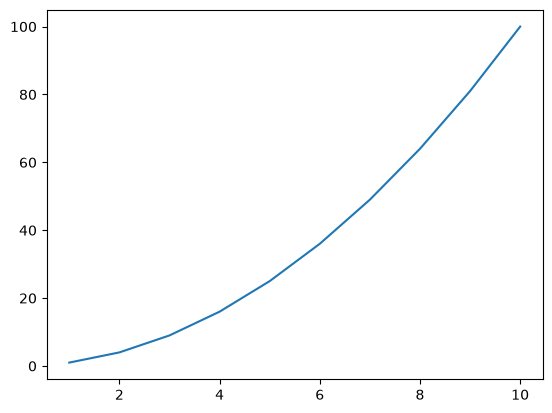

In [112]:
# y=x^2
x
y=x**2
plt.plot(x,y)

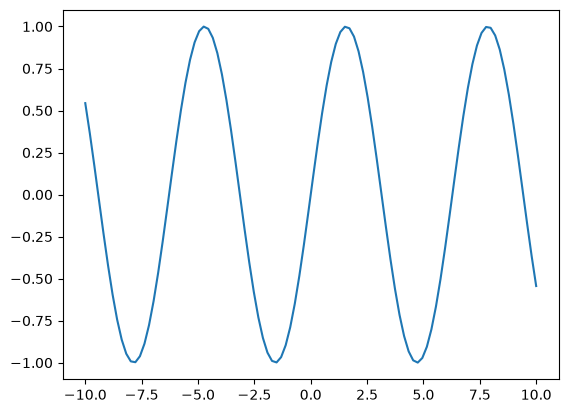

In [115]:
x=np.linspace(-10,10,100)
# 100 values between -10 to 10
y=np.sin(x)
plt.plot(x,y)